In [35]:
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
import matplotlib.pyplot as plt

In [36]:
# This is the training data

# Load the Dataset
mnist = tf.keras.datasets.mnist
# Created the train test of the data
(X_train, y_train), (x_test, y_test) = mnist.load_data()

print(X_train.shape)
print(X_train[0].shape)
# 60000 examles with 28x28 images
# 28 rows : 28 pixels that is sequntial



# NOrmalization
X_train = X_train/255
x_test = x_test/255


(60000, 28, 28)
(28, 28)


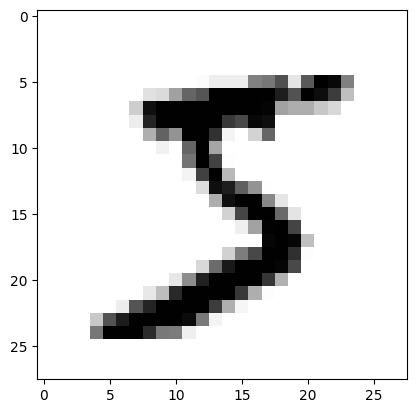

In [37]:
plt.imshow(X_train[0], cmap = plt.cm.binary)
plt.show()

In [16]:
model = Sequential()

# Adding the layers

# Layer1
model.add(LSTM(128, input_shape=(X_train.shape[1:]), return_sequences=True))
model.add(Dropout(0.2))

# Layer2
model.add(LSTM(128, activation='relu'))
model.add(Dropout(0.2))

# Layer3
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Layer4
model.add(Dense(10, activation='softmax'))




c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# To Compile we optimize
opt = tf.keras.optimizers.Adam(learning_rate=1e-3, decay=1e-5)

# Mean Square Error
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])


c:\Users\abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [18]:
model.fit(X_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 119s 58ms/step - accuracy: 0.8163 - loss: 0.5663 - val_accuracy: 0.9439 - val_loss: 0.1862
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 108s 57ms/step - accuracy: 0.9602 - loss: 0.1484 - val_accuracy: 0.9752 - val_loss: 0.0899
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 98s 52ms/step - accuracy: 0.9745 - loss: 0.0971 - val_accuracy: 0.9830 - val_loss: 0.0557


In [19]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print(val_loss, val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9830 - loss: 0.0557
0.055657390505075455 0.9829999804496765


In [24]:
model.save('epic_num.keras')

In [26]:

new_model = tf.keras.models.load_model('epic_num.keras')

In [38]:

prediction = new_model.predict([x_test])

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [28]:
print(prediction)

[[4.07441803e-07 8.46974035e-06 5.93549084e-05 ... 9.99755681e-01
  5.32192416e-07 4.96219291e-05]
 [8.29874502e-11 2.06079722e-08 1.00000000e+00 ... 1.44759476e-08
  2.30241895e-10 6.35535721e-12]
 [1.01111750e-08 9.99947906e-01 2.65865947e-05 ... 7.85356497e-06
  1.69958603e-05 6.40401439e-08]
 ...
 [8.72785259e-30 6.35008456e-24 1.46483065e-17 ... 7.31610044e-16
  4.09854593e-17 3.61810498e-10]
 [4.52718751e-09 1.65510083e-09 3.78244316e-08 ... 2.34802466e-09
  9.93188564e-07 3.99346245e-05]
 [3.74128839e-10 5.27825179e-12 4.81131857e-10 ... 7.47968950e-16
  5.64772534e-11 1.32336815e-11]]


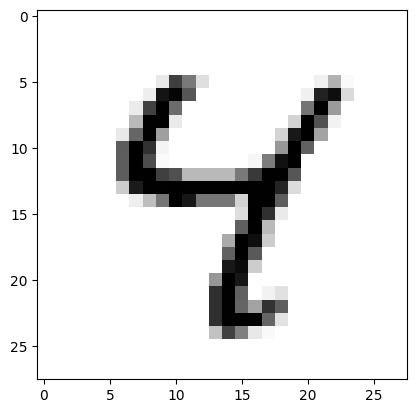

In [41]:
plt.imshow(x_test[6], cmap = plt.cm.binary)

In [42]:
import numpy as np

print(np.argmax(prediction[6]))


4
